# Étape 3 & 4 : Gestion du déséquilibre & Modélisation supervisée

## Contexte
Notre dataset contient 0.17% de fraudes (492 sur 284 807). Un modèle entraîné 
sur ces données brutes apprendra à prédire "légitime" systématiquement, 
atteignant 99.83% d'accuracy sans détecter une seule fraude.

## Stratégie
Il n'existe pas de méthode universelle pour gérer le déséquilibre. Chaque 
approche fait un compromis différent :

- **SMOTE** : génère des fraudes synthétiques pour équilibrer les classes. 
  Risque : créer des exemples irréalistes.
- **Under-sampling** : réduit les transactions légitimes. 
  Risque : perdre de l'information utile.
- **Pondération des classes** : pénalise davantage les erreurs sur les fraudes. 
  Risque : peut augmenter les fausses alertes.

Nous testerons chaque approche combinée à trois modèles (Logistic Regression, 
Random Forest, XGBoost) pour déterminer empiriquement la meilleure combinaison 
sur nos données. C'est le résultat qui tranche, pas la théorie.

## 3.1 — Chargement des données et rééquilibrage

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, f1_score,
                             precision_score, recall_score)
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# Chargement des données prétraitées
with open('../outputs/preprocessed_data.pkl', 'rb') as f:
    data = pickle.load(f)

X_train = data['X_train']
X_test = data['X_test']
y_train = data['y_train']
y_test = data['y_test']

print(f"Train : {X_train.shape[0]} transactions, {y_train.sum()} fraudes ({y_train.mean()*100:.3f}%)")
print(f"Test  : {X_test.shape[0]} transactions, {y_test.sum()} fraudes ({y_test.mean()*100:.3f}%)")

Train : 227845 transactions, 394 fraudes (0.173%)
Test  : 56962 transactions, 98 fraudes (0.172%)


## 3.2 — Création des 3 stratégies de rééquilibrage

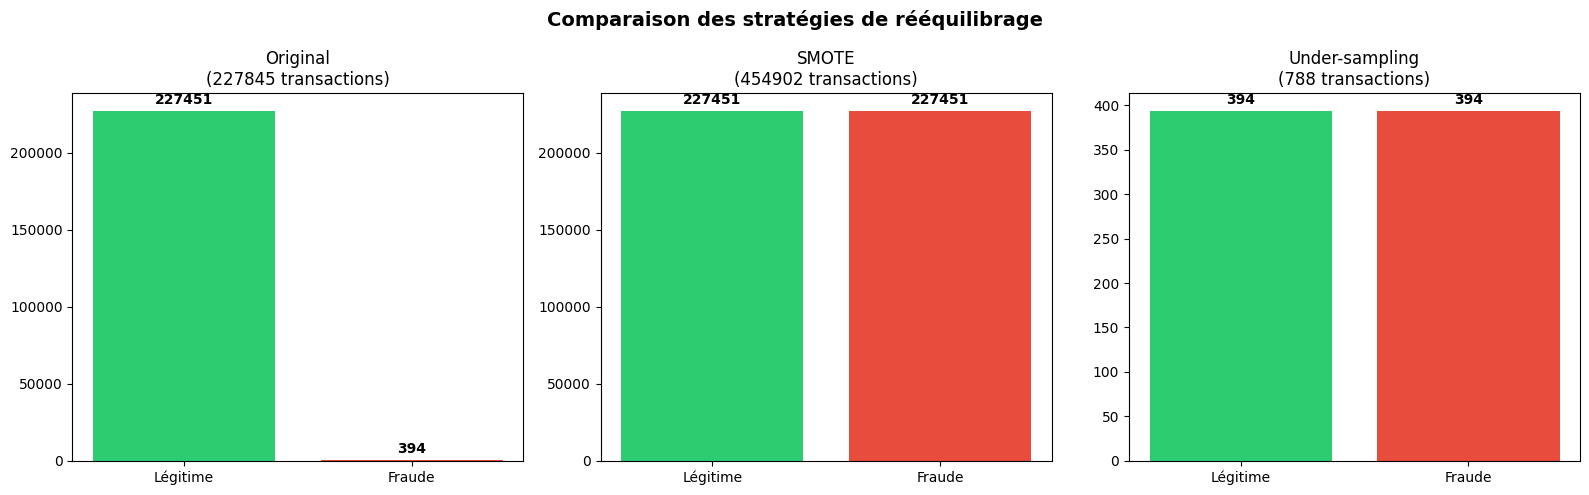


Pondération : 1 fraude = 577 légitimes


In [3]:
# STRATÉGIE 1 : SMOTE (sur-échantillonnage synthétique)
# Crée des fraudes artificielles en interpolant entre les fraudes existantes
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# STRATÉGIE 2 : Under-sampling (sous-échantillonnage aléatoire)
# Réduit les légitimes au même nombre que les fraudes
under = RandomUnderSampler(random_state=42)
X_train_under, y_train_under = under.fit_resample(X_train, y_train)

# STRATÉGIE 3 : Pondération (pas de modification des données)
# On calculera le ratio pour le passer aux modèles
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

# Résumé visuel
strategies = {
    'Original': y_train,
    'SMOTE': y_train_smote,
    'Under-sampling': y_train_under
}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, (name, y) in enumerate(strategies.items()):
    counts = pd.Series(y).value_counts()
    colors = ['#2ecc71', '#e74c3c']
    axes[i].bar(counts.index, counts.values, color=colors)
    axes[i].set_title(f'{name}\n({len(y)} transactions)')
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(['Légitime', 'Fraude'])
    for j, v in enumerate(counts.values):
        axes[i].text(j, v + max(counts.values)*0.02, str(v), 
                     ha='center', fontweight='bold')

plt.suptitle('Comparaison des stratégies de rééquilibrage', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/resampling_strategies.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nPondération : 1 fraude = {scale_pos_weight:.0f} légitimes")

### Observations sur les stratégies de rééquilibrage

- **Original** : 227 451 légitimes vs 394 fraudes. Le déséquilibre extrême 
  risque de biaiser le modèle vers la classe majoritaire.

- **SMOTE** : génère 227 057 fraudes synthétiques par interpolation entre 
  fraudes existantes, portant le total à 454 902 transactions équilibrées. 
  On double le volume de données mais les fraudes ajoutées sont artificielles.

- **Under-sampling** : réduit les légitimes à 394, soit 788 transactions au 
  total. L'équilibre est atteint mais on perd 99.8% des données légitimes, 
  donc potentiellement beaucoup d'information.

- **Pondération** : 1 fraude pèse autant que 577 légitimes. Aucune 
  modification des données — le modèle ajuste ses calculs internes.

Chaque approche fait un compromis différent. Seule la comparaison des 
performances sur le jeu de test permettra de déterminer laquelle est la 
plus adaptée à notre problème.

## 3.3 — Entraînement : 3 modèles × 3 stratégies

On teste chaque combinaison modèle/stratégie pour trouver la meilleure. 
Les trois modèles ont des niveaux de complexité croissants :
- **Logistic Regression** : simple, rapide, interprétable. Notre baseline.
- **Random Forest** : ensemble d'arbres de décision, capture les non-linéarités.
- **XGBoost** : gradient boosting, souvent le plus performant en compétition.

In [6]:
# Définition des modèles
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
}

# Définition des stratégies (données + modèles avec pondération)
strategies = {
    'Original': (X_train, y_train),
    'SMOTE': (X_train_smote, y_train_smote),
    'Under-sampling': (X_train_under, y_train_under),
}

# Stockage des résultats
results = []

for strat_name, (X_tr, y_tr) in strategies.items():
    for model_name, model in models.items():
        
        # Clone du modèle pour chaque itération
        from sklearn.base import clone
        clf = clone(model)
        
        print(f"Entraînement : {model_name} + {strat_name}...", end=" ")
        clf.fit(X_tr, y_tr)
        
        # Prédictions sur le jeu de test
        y_pred = clf.predict(X_test)
        y_proba = clf.predict_proba(X_test)[:, 1]
        
        # Calcul des métriques
        result = {
            'Modèle': model_name,
            'Stratégie': strat_name,
            'Precision': precision_score(y_test, y_pred),
            'Recall': recall_score(y_test, y_pred),
            'F1': f1_score(y_test, y_pred),
            'AUC-ROC': roc_auc_score(y_test, y_proba),
            'model': clf,
            'y_pred': y_pred,
            'y_proba': y_proba
        }
        results.append(result)
        print(f"OK — F1={result['F1']:.3f}, Recall={result['Recall']:.3f}")

# Tableau récapitulatif
results_df = pd.DataFrame(results).drop(columns=['model', 'y_pred', 'y_proba'])
results_df = results_df.sort_values('F1', ascending=False)
print("\n=== CLASSEMENT PAR F1-SCORE ===")
print(results_df.to_string(index=False))

Entraînement : Logistic Regression + Original... OK — F1=0.739, Recall=0.663
Entraînement : Random Forest + Original... OK — F1=0.867, Recall=0.796
Entraînement : XGBoost + Original... OK — F1=0.828, Recall=0.786
Entraînement : Logistic Regression + SMOTE... OK — F1=0.114, Recall=0.908
Entraînement : Random Forest + SMOTE... OK — F1=0.836, Recall=0.806
Entraînement : XGBoost + SMOTE... OK — F1=0.817, Recall=0.867
Entraînement : Logistic Regression + Under-sampling... OK — F1=0.073, Recall=0.918
Entraînement : Random Forest + Under-sampling... OK — F1=0.080, Recall=0.908
Entraînement : XGBoost + Under-sampling... OK — F1=0.064, Recall=0.918

=== CLASSEMENT PAR F1-SCORE ===
             Modèle      Stratégie  Precision   Recall       F1  AUC-ROC
      Random Forest       Original   0.951220 0.795918 0.866667 0.952827
      Random Forest          SMOTE   0.868132 0.806122 0.835979 0.982340
            XGBoost       Original   0.875000 0.785714 0.827957 0.940489
            XGBoost        

## 3.4 — Modèles avec pondération des classes

In [7]:
models_weighted = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, random_state=42, class_weight='balanced'
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100, random_state=42, n_jobs=-1, class_weight='balanced'
    ),
    'XGBoost': XGBClassifier(
        n_estimators=100, random_state=42, eval_metric='logloss',
        scale_pos_weight=scale_pos_weight
    )
}

for model_name, clf in models_weighted.items():
    print(f"Entraînement : {model_name} + Pondération...", end=" ")
    clf.fit(X_train, y_train)
    
    y_pred = clf.predict(X_test)
    y_proba = clf.predict_proba(X_test)[:, 1]
    
    result = {
        'Modèle': model_name,
        'Stratégie': 'Pondération',
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'AUC-ROC': roc_auc_score(y_test, y_proba),
        'model': clf,
        'y_pred': y_pred,
        'y_proba': y_proba
    }
    results.append(result)
    print(f"OK — F1={result['F1']:.3f}, Recall={result['Recall']:.3f}")

# Tableau final avec les 12 combinaisons
results_df = pd.DataFrame(results).drop(columns=['model', 'y_pred', 'y_proba'])
results_df = results_df.sort_values('F1', ascending=False)
print("\n=== CLASSEMENT FINAL PAR F1-SCORE ===")
print(results_df.to_string(index=False))

Entraînement : Logistic Regression + Pondération... OK — F1=0.106, Recall=0.918
Entraînement : Random Forest + Pondération... OK — F1=0.846, Recall=0.755
Entraînement : XGBoost + Pondération... OK — F1=0.860, Recall=0.847

=== CLASSEMENT FINAL PAR F1-SCORE ===
             Modèle      Stratégie  Precision   Recall       F1  AUC-ROC
      Random Forest       Original   0.951220 0.795918 0.866667 0.952827
            XGBoost    Pondération   0.873684 0.846939 0.860104 0.974578
      Random Forest    Pondération   0.961039 0.755102 0.845714 0.957990
      Random Forest          SMOTE   0.868132 0.806122 0.835979 0.982340
            XGBoost       Original   0.875000 0.785714 0.827957 0.940489
            XGBoost          SMOTE   0.772727 0.867347 0.817308 0.985843
Logistic Regression       Original   0.833333 0.663265 0.738636 0.958582
Logistic Regression          SMOTE   0.060876 0.908163 0.114103 0.972657
Logistic Regression    Pondération   0.056391 0.918367 0.106257 0.972667
      Ran

### Analyse des résultats

**Under-sampling** : Recall élevé (~0.92) mais Précision catastrophique (~0.03). 
Le modèle flag presque tout comme fraude pour ne rien rater — inutilisable 
en production (97% de fausses alertes).

**Original** : bonne Précision mais Recall limité. Le modèle est conservateur — 
quand il alerte, c'est fiable, mais il laisse passer ~20% des fraudes.

**SMOTE et Pondération** offrent les meilleurs compromis. XGBoost + Pondération 
se distingue avec le meilleur F1 (0.86), un bon équilibre Précision/Recall 
(0.87/0.85), et le meilleur AUC-ROC (0.975).

**Conclusion** : la pondération des classes est la stratégie la plus efficace 
sur nos données. Elle ne modifie pas le dataset et laisse le modèle ajuster 
son apprentissage. XGBoost + Pondération sera notre modèle de référence pour 
la suite.

## 3.5 — Courbes ROC et matrices de confusion
Visualisation des performances des meilleurs modèles pour comparer 
leur capacité à séparer fraudes et légitimes.

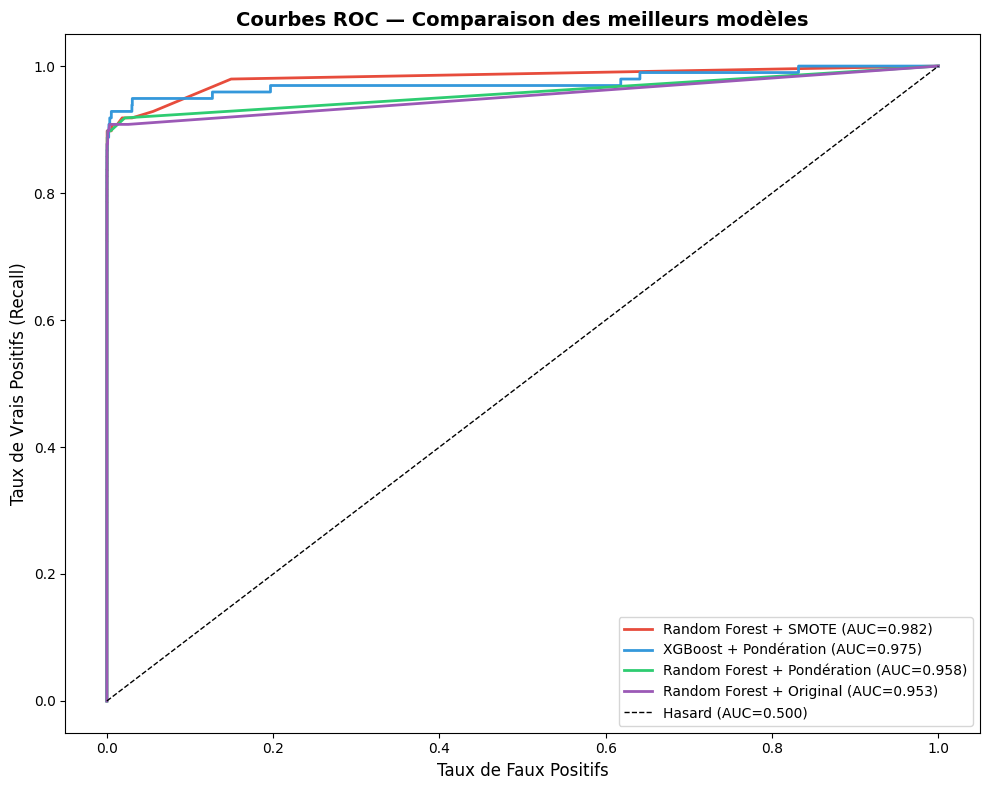

In [10]:
# Sélection des 4 meilleures combinaisons
top_models = [r for r in results if r['F1'] > 0.83]

fig, ax = plt.subplots(figsize=(10, 8))

colors = ['#e74c3c', '#3498db', '#2ecc71', '#9b59b6', '#f39c12', '#1abc9c']

for i, r in enumerate(sorted(top_models, key=lambda x: x['AUC-ROC'], reverse=True)):
    fpr, tpr, _ = roc_curve(y_test, r['y_proba'])
    label = f"{r['Modèle']} + {r['Stratégie']} (AUC={r['AUC-ROC']:.3f})"
    ax.plot(fpr, tpr, color=colors[i], linewidth=2, label=label)

# Ligne du hasard (modèle aléatoire)
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Hasard (AUC=0.500)')

ax.set_xlabel('Taux de Faux Positifs', fontsize=12)
ax.set_ylabel('Taux de Vrais Positifs (Recall)', fontsize=12)
ax.set_title('Courbes ROC — Comparaison des meilleurs modèles', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)

plt.tight_layout()
plt.savefig('../outputs/roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

### Analyse des courbes ROC

Toutes les courbes sont nettement au-dessus de la diagonale (hasard), 
confirmant que nos modèles ont un réel pouvoir discriminant.

Random Forest + SMOTE obtient le meilleur AUC (0.982), suivi de XGBoost + Pondération (0.975). Cela signifie que ces modèles séparent bien les 
fraudes des légitimes quel que soit le seuil choisi.

## 3.6 — Matrices de confusion des 3 meilleurs modèles

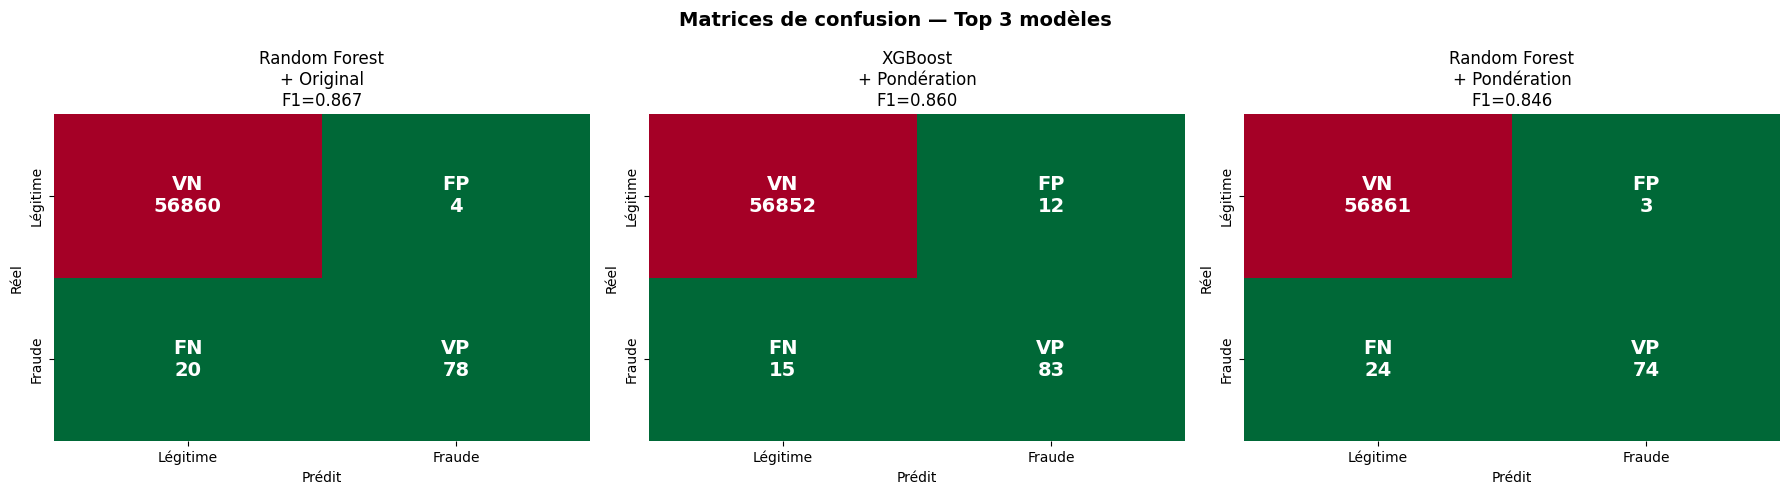

=== LECTURE DE LA MATRICE ===
VN (Vrai Négatif)  : légitime correctement identifié ✓
VP (Vrai Positif)  : fraude correctement détectée ✓
FP (Faux Positif)  : légitime flaggé comme fraude ✗ (fausse alerte)
FN (Faux Négatif)  : fraude non détectée ✗ (le pire en anti-fraude)


In [11]:
# Top 3 par F1
top3 = sorted(top_models, key=lambda x: x['F1'], reverse=True)[:3]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, r in enumerate(top3):
    cm = confusion_matrix(y_test, r['y_pred'])
    
    # Annotation avec les labels explicites
    labels = np.array([
        [f"VN\n{cm[0][0]}", f"FP\n{cm[0][1]}"],
        [f"FN\n{cm[1][0]}", f"VP\n{cm[1][1]}"]
    ])
    
    sns.heatmap(cm, annot=labels, fmt='', cmap='RdYlGn_r',
                xticklabels=['Légitime', 'Fraude'],
                yticklabels=['Légitime', 'Fraude'],
                ax=axes[i], cbar=False,
                annot_kws={'size': 14, 'fontweight': 'bold'})
    
    axes[i].set_xlabel('Prédit')
    axes[i].set_ylabel('Réel')
    axes[i].set_title(f"{r['Modèle']}\n+ {r['Stratégie']}\nF1={r['F1']:.3f}")

plt.suptitle('Matrices de confusion — Top 3 modèles', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

# Explication des quadrants
print("=== LECTURE DE LA MATRICE ===")
print("VN (Vrai Négatif)  : légitime correctement identifié ✓")
print("VP (Vrai Positif)  : fraude correctement détectée ✓")
print("FP (Faux Positif)  : légitime flaggé comme fraude ✗ (fausse alerte)")
print("FN (Faux Négatif)  : fraude non détectée ✗ (le pire en anti-fraude)")

### Analyse des matrices de confusion

Le quadrant le plus coûteux est **FN (Faux Négatif)** : une fraude non 
détectée entraîne une perte financière directe pour la banque et le client.

- **XGBoost + Pondération** : 15 fraudes ratées, 12 fausses alertes. 
  Meilleur compromis — minimise les fraudes manquées avec peu de 
  fausses alertes.
- **Random Forest + Original** : 20 fraudes ratées, seulement 4 fausses 
  alertes. Très précis mais trop conservateur.
- **Random Forest + Pondération** : 24 fraudes ratées. Le moins bon 
  des trois sur l'objectif principal.

**Choix retenu** : XGBoost + Pondération offre le meilleur compromis 
entre détection des fraudes et maîtrise des fausses alertes.

## Conclusion — Étape 3 & 4

Nous avons testé 12 combinaisons (3 modèles × 4 stratégies de rééquilibrage).

**Meilleur modèle : XGBoost + Pondération**
- Meilleur compromis global : F1=0.860, Precision=0.874, Recall=0.847
- Meilleur AUC-ROC (0.975) : forte capacité de séparation des classes
- Seulement 15 fraudes non détectées (FN) avec 12 fausses alertes (FP)

**Random Forest + Original et SMOTE** restent des candidats intéressants 
avec des profils différents (plus précis mais moins de recall).

Tous les modèles ont été entraînés avec les hyperparamètres par défaut. 
Une optimisation des hyperparamètres pourrait améliorer significativement 
les performances. Nous conservons donc les meilleurs candidats pour 
une comparaison finale à l'Étape 6.